In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc

import os

import scvi 


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

In [80]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000_mixD2_threshold'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')

In [10]:
entropy_peak, peak, h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 2033 × 37959
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2033 × 32338
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 104068 × 687495,
 (104068, 6),
 (687495, 1),
 (736320, 2))

## plot atac clustering results

In [325]:
# atac clsutering at different resolutions
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_all', resolution=atac_resolution)

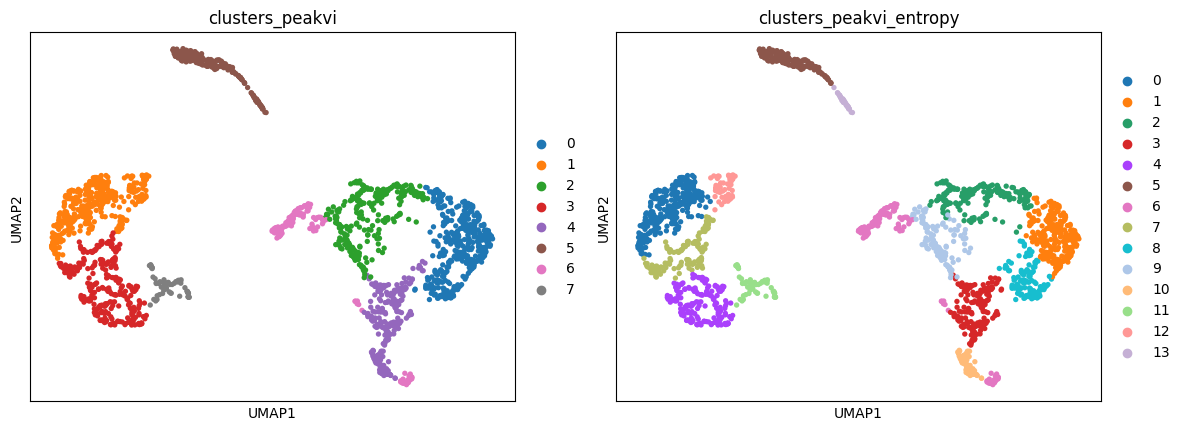

In [326]:
sc.pl.umap(entropy_peak, color=['clusters_peakvi', 'clusters_peakvi_entropy'], wspace=0.1)

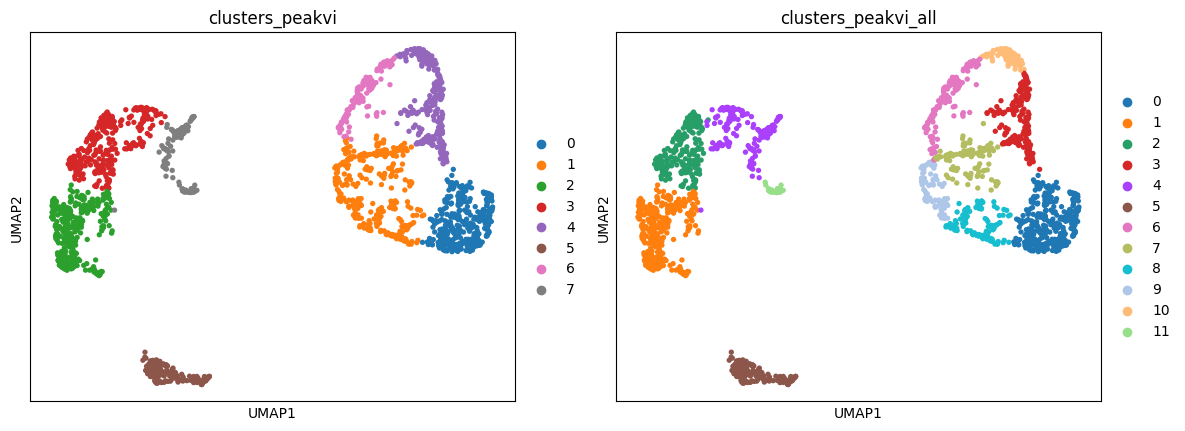

In [327]:
sc.pl.umap(peak, color=['clusters_peakvi', 'clusters_peakvi_all'], wspace=0.1)

In [330]:
entropy_peak.obs.head()

,barcodes,_scvi_batch,_scvi_labels,clusters_peakvi,rna_barcodes,clusters_peakvi_entropy,leiden_RNA_scVI
atac_bc,,,,,,,
TGAGGCATCATCAGTT,TGAGGCATCATCAGTT-1,0,0,0,GATTTGCAGCATCCAG,8,1
ACTCCTAAGTCTTAGT,ACTCCTAAGTCTTAGT-1,0,0,6,TCATGTTTCTTAGCCC,6,4
CCAAGTGAGGTGCTGA,CCAAGTGAGGTGCTGA-1,0,0,1,GTGTAACTCGAAGTAG,0,7
GCACCTTAGAGGAACA,GCACCTTAGAGGAACA-1,0,0,2,ACAGCGCTCTGTTGCC,9,2
CCTTATGAGGATAACC,CCTTATGAGGATAACC-1,0,0,2,CTGAAACTCGTTATAG,2,1


In [331]:
entropy_peak_df = entropy_peak.obs.copy()
entropy_peak_df.set_index('barcodes', inplace=True)

peak_df = peak.obs.copy()
peak_df.set_index('barcodes', inplace=True)

a= peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)
# a.columns = [i  +'_' + a.columns.name  for i in a.columns.values]
# a.to_csv(os.path.join(entropy_downstream_dir, 'clustering_comparison_tb.csv'), sep='\t', index=True,header=True)
a


/tmp/ipykernel_2378580/3647149105.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a= peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)


clusters_peakvi_entropy,0,1,2,3,4,5,6,7,8,9,10,11,12,13
clusters_peakvi_all,,,,,,,,,,,,,,
0,0,245,4,5,0,1,0,0,102,0,0,0,1,0
1,282,0,0,1,0,0,0,14,0,0,1,1,45,0
2,16,0,0,0,87,0,0,109,0,0,0,0,0,0
3,0,0,0,165,0,0,3,0,9,1,3,0,1,0
4,0,0,0,0,82,0,0,2,0,1,0,72,9,2
5,0,0,1,0,0,163,0,0,0,0,0,0,2,1
6,0,0,3,0,0,0,138,0,0,5,0,0,0,0
7,0,0,4,3,0,0,3,0,6,108,0,0,0,0
8,0,16,97,0,0,0,0,0,4,0,0,0,0,1


In [192]:
# Now manually map the best matching clusters
clusters_map = {'0':'0',
'1':'2',
'2':'1',
'3':'3',
'4':'4',
'5':'5',
'6':'6',
'7':'7',}
peak.obs['clusters_peakvi_all'] = peak.obs['clusters_peakvi'].map(clusters_map)
peak.obs['clusters_peakvi_all'] = peak.obs['clusters_peakvi_all'].cat.reorder_categories(['0', '1', '2', '3', '4', '5', '6', '7'], ordered=False)


## Matching atac bc with RNA bc

In [ ]:
bc_map = bc_map_pd.set_index('atac_barcodes')

entropy_peak.obs['atac_bc'] =  entropy_peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
entropy_peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in entropy_peak.obs.columns:
    entropy_peak.obs = entropy_peak.obs.join(bc_map, how='inner')


peak.obs['atac_bc'] =  peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in peak.obs.columns:
    peak.obs = peak.obs.join(bc_map, how='inner')


entropy_passed_bc_map = entropy_peak.obs[['rna_barcodes']]

In [110]:
entropy_peak.obs.head()

,barcodes,_scvi_batch,_scvi_labels,clusters_peakvi,rna_barcodes
atac_bc,,,,,
TGAGGCATCATCAGTT,TGAGGCATCATCAGTT-1,0,0,0,GATTTGCAGCATCCAG
ACTCCTAAGTCTTAGT,ACTCCTAAGTCTTAGT-1,0,0,6,TCATGTTTCTTAGCCC
CCAAGTGAGGTGCTGA,CCAAGTGAGGTGCTGA-1,0,0,1,GTGTAACTCGAAGTAG
GCACCTTAGAGGAACA,GCACCTTAGAGGAACA-1,0,0,2,ACAGCGCTCTGTTGCC
CCTTATGAGGATAACC,CCTTATGAGGATAACC-1,0,0,2,CTGAAACTCGTTATAG


In [106]:
entropy_passed_bc_map 


,rna_barcodes
atac_bc,
TGAGGCATCATCAGTT,GATTTGCAGCATCCAG
ACTCCTAAGTCTTAGT,TCATGTTTCTTAGCCC
CCAAGTGAGGTGCTGA,GTGTAACTCGAAGTAG
GCACCTTAGAGGAACA,ACAGCGCTCTGTTGCC
CCTTATGAGGATAACC,CTGAAACTCGTTATAG
...,...
TGCTGGTTCACAAATG,GTGTTACAGTCACCAG
GCCAAACCACTTGCTG,TGTATCCGTTCGCTTG
TCTTGGATCAGTACCC,CATCCTCAGGGATTAG


## RNA clustering

In [343]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
entropy_passed_bc_map.reset_index(inplace=True)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)


h5_rna = h5.transpose()
h5_rna.obs['rna_barcodes'] = h5_rna.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna = h5_rna[:, h5_rna.var['feature_type'] == 'Gene Expression']
h5_rna = h5_rna[h5_rna.obs.index.isin(entropy_passed_bc_map.index), :]
h5_rna.obs = h5_rna.obs.join(entropy_passed_bc_map, how='inner')


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [344]:
h5_rna

AnnData object with n_obs × n_vars = 2033 × 36601
    obs: 'barcodes', 'index', 'atac_bc'
    var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'

In [345]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [346]:
scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
vae = scvi.model.SCVI(h5_rna, n_layers=2, n_latent=30, gene_likelihood="nb")
vae.train()
h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()


sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
sc.tl.umap(h5_rna, min_dist=0.3)

# clustering using scVI latent representation via Leiden
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=0.5)

# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae_model_folder=os.path.join(args.o[0], "integrated_scvi_model")
# vae.save(vae_model_folder)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` 

Epoch 400/400: 100%|██████████| 400/400 [01:25<00:00,  4.40it/s, v_num=1, train_loss_step=5.65e+3, train_loss_epoch=5.35e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:25<00:00,  4.66it/s, v_num=1, train_loss_step=5.65e+3, train_loss_epoch=5.35e+3]


In [347]:
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=atac_resolution) # set the same resolution as atac clustering

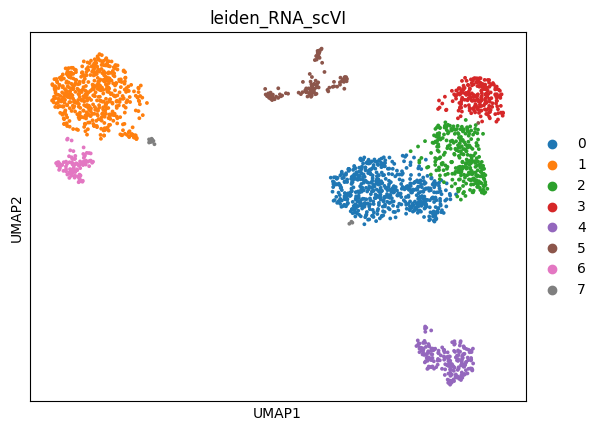

In [348]:
sc.pl.umap(h5_rna, color=['leiden_RNA_scVI'], wspace=0.2, size=30)

In [349]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'clusters_peakvi_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_all', axis=1, inplace=True)

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy']], left_on='atac_bc', right_index=True, how='left')
# h5_rna.obs.rename(columns={'clusters_peakvi':'clusters_peakvi_entropy'}, inplace=True)
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_all']], left_on='atac_bc', right_index=True, how='left')
#h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi']], left_on='atac_bc', right_index=True, how='left')
#h5_rna.obs.rename(columns={'clusters_peakvi':'clusters_peakvi_all'}, inplace=True)

In [350]:
h5_rna.obs.head()

,barcodes,index,atac_bc,_scvi_batch,_scvi_labels,leiden_RNA_scVI,clusters_peakvi_entropy,clusters_peakvi_all
rna_barcodes,,,,,,,,
AAACAGCCAGGCTACT,AAACAGCCAGGCTACT-1,1718,ACAGCGGGTTTGTAGC,0,0,0,1,0
AAACATGCAAGGATTA,AAACATGCAAGGATTA-1,129,CATTTAGGTAACAGCA,0,0,2,9,7
AAACATGCAGAACCGA,AAACATGCAGAACCGA-1,102,CATTTAGGTTAATCGC,0,0,0,2,9
AAACCAACACATACTG,AAACCAACACATACTG-1,1463,CTTTATCGTCGGTTCA,0,0,3,6,6
AAACCAACAGCCTAAC,AAACCAACAGCCTAAC-1,1091,CTTTATCGTAAACCAG,0,0,2,9,7


In [351]:
h5_rna.obs.groupby(['leiden_RNA_scVI', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)

/tmp/ipykernel_2378580/3343562059.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['leiden_RNA_scVI', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)


clusters_peakvi_entropy,0,1,2,3,4,5,6,7,8,9,10,11,12,13
leiden_RNA_scVI,,,,,,,,,,,,,,
0,0,256,182,8,0,0,1,0,105,11,0,4,1,0
1,220,0,0,0,162,1,0,110,2,1,0,30,7,0
2,0,0,7,152,0,0,18,0,12,102,4,1,2,0
3,0,1,1,9,0,0,124,0,0,1,71,0,1,0
4,0,1,5,2,0,158,1,0,0,1,0,0,0,32
5,6,3,2,8,0,3,2,1,2,5,4,34,46,0
6,72,0,0,0,7,0,0,14,0,0,0,3,2,0
7,0,0,1,0,0,2,0,0,0,0,0,1,1,7


In [352]:
h5_rna.obs.groupby(['leiden_RNA_scVI',  'clusters_peakvi_all']).size().unstack(fill_value=0)

/tmp/ipykernel_2378580/1878967965.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['leiden_RNA_scVI',  'clusters_peakvi_all']).size().unstack(fill_value=0)


clusters_peakvi_all,0,1,2,3,4,5,6,7,8,9,10,11
leiden_RNA_scVI,,,,,,,,,,,,
0,342,1,0,10,4,0,3,14,110,83,0,1
1,0,225,192,1,112,1,0,1,1,0,0,0
2,10,1,0,155,2,0,16,105,2,5,2,0
3,1,0,0,6,1,0,123,0,0,1,76,0
4,1,1,0,1,0,158,1,0,5,3,0,30
5,3,42,2,9,40,6,3,4,0,1,5,1
6,1,73,18,0,6,0,0,0,0,0,0,0
7,0,1,0,0,3,2,0,0,0,1,0,5


## Plot to see consistency between atac space and rna space 

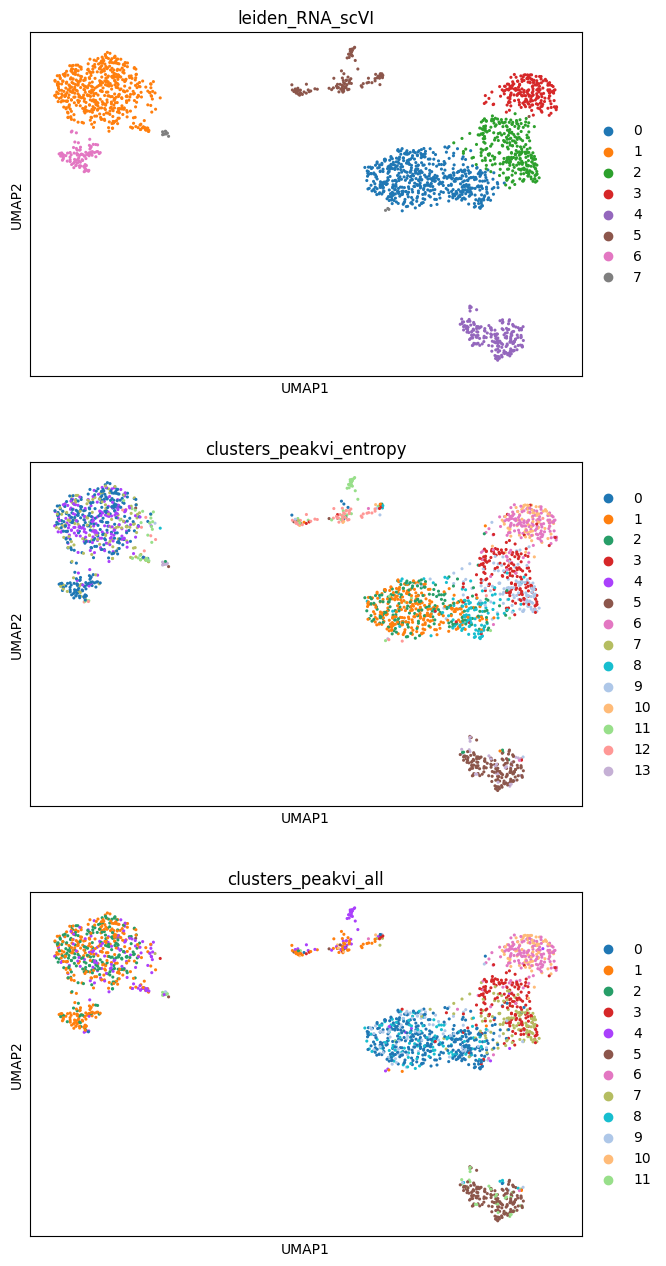

In [353]:
sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'clusters_peakvi_entropy', 'clusters_peakvi_all'], wspace=0.2, ncols=1, size=20)

In [354]:
if 'leiden_RNA_scVI' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
if 'leiden_RNA_scVI' in peak.obs.columns:
    peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')
peak.obs = peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')

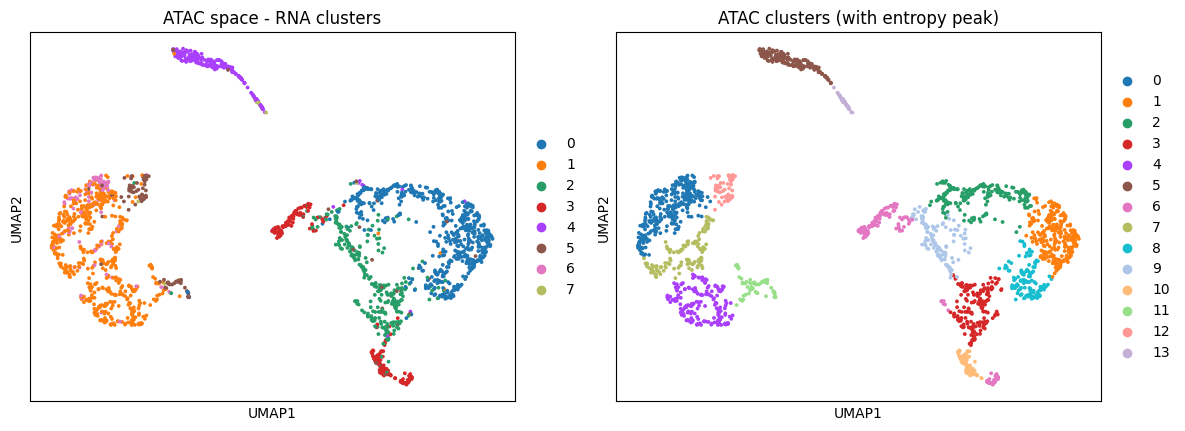

In [357]:
sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI', 'clusters_peakvi_entropy'], wspace=0.1,title=['ATAC space - RNA clusters', 'ATAC clusters (with entropy peak)'], size=30)

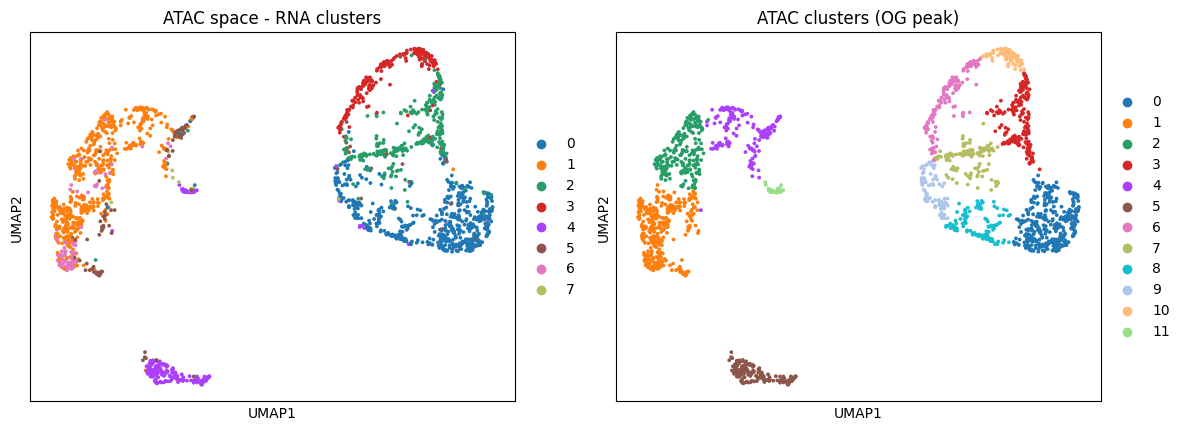

In [358]:
sc.pl.umap(peak, color=['leiden_RNA_scVI', 'clusters_peakvi_all'], wspace=0.1, title=['ATAC space - RNA clusters', 'ATAC clusters (OG peak)'], size=30)

In [372]:
37959/ 32338 * 100

117.38202733626075

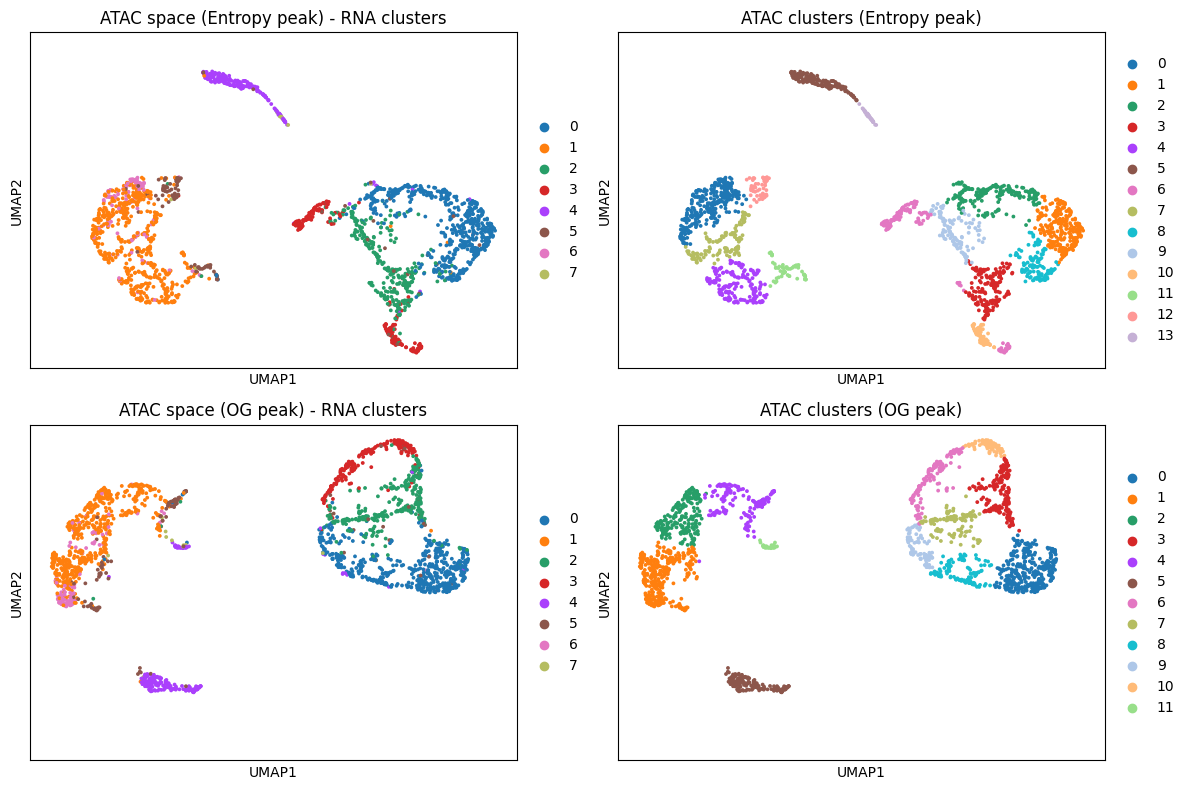

In [368]:
fig, ax = plt.subplots(2, 2, figsize=(12,8), sharex=True, sharey=True)
ax = ax.flatten()
sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI'], title='ATAC space (Entropy peak) - RNA clusters', size=30, ax=ax[0], show=False)
sc.pl.umap(entropy_peak, color=['clusters_peakvi_entropy'], title='ATAC clusters (Entropy peak)', size=30, ax=ax[1], show=False)
sc.pl.umap(peak, color=['leiden_RNA_scVI'], title='ATAC space (OG peak) - RNA clusters', size=30, ax=ax[2], show=False)
sc.pl.umap(peak, color=['clusters_peakvi_all'], title='ATAC clusters (OG peak)', size=30, ax=ax[3], show=False)

fig.tight_layout()